In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [2]:
# set pandas display options for better readability
pd.set_option('display.max_columns', None)

## --- PART I ---

In [3]:
# --- Task 1 Data Preparation & Cleaning Function ---
def clean_data(file_path):
    print(f"Processing file: {file_path} ...")
    
    # 1. load data
    keep_cols = [
        'id', 'price', 'property_type', 'room_type', 'accommodates', 
        'bedrooms', 'beds', 'bathrooms_text', 'amenities', 'review_scores_rating', 
        'number_of_reviews', 'neighbourhood_cleansed'
    ]
    
    # selective reading based on file extension
    if file_path.endswith('.gz'):
        df = pd.read_csv(file_path)[keep_cols]
    else:
        df = pd.read_csv(file_path)[keep_cols]

    # 2. wrangle price column
    if df['price'].dtype == 'O':
        df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)
    
    # filter out extreme prices
    df = df[(df['price'] > 10) & (df['price'] < 1000)]
    
    # 3. process missing values
    # define columns to fill
    cols_to_fill = ['bedrooms', 'beds', 'review_scores_rating']
    
    for col in cols_to_fill:
        # 1. create flag for missingness
        df[f'flag_{col}'] = df[col].isna().astype(int)
        # 2. fill missing with median
        df[col] = df[col].fillna(df[col].median())
    
    # special handling for bathrooms_text
    df['n_bathrooms'] = df['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)
    df['flag_n_bathrooms'] = df['n_bathrooms'].isna().astype(int) # create flag
    df['n_bathrooms'] = df['n_bathrooms'].fillna(df['n_bathrooms'].median())
    
    # 4. process amenities
    target_amenities = ['Wifi', 'Air conditioning', 'Kitchen', 'Heating', 'Washer', 'Elevator', 'TV']
    
    df['amenities'] = df['amenities'].astype(str).str.lower()
    
    for amenity in target_amenities:
        col_name = f'd_{amenity.replace(" ", "_").lower()}'
        search_term = amenity.lower()
        df[col_name] = df['amenities'].str.contains(search_term).astype(int)
        
    # 5. filter property types

    typical_types = ['Entire rental unit', 'Private room in rental unit', 'Entire condo', 'Entire home']
    
    # 6. create log price target
    df['ln_price'] = np.log(df['price'])
    
    print(f"Processing complete. Rows remaining: {len(df)}")
    return df

### Variable Selection and Feature Engineering Choices

1. **Target Variable: Log-Price (`ln_price`)**
   I chose to predict the logarithm of the price rather than the raw dollar amount. Real estate data is usually "skewed"—there are many affordable listings and a few ultra-expensive luxury ones. Using the log-price makes the data look more like a standard bell curve (normal distribution), which helps linear models work better. It also means the model focuses on minimizing percentage errors (e.g., being 10% off) rather than just dollar errors, which is fairer for both cheap and expensive listings.

2. **Sample Design: Filtering Outliers**
   To simulate a real-world business case, I filtered out listings with extreme prices (e.g., >$1,000 or <$10). These "outliers" often represent data errors or extremely niche luxury properties that follow different pricing rules. By removing them, I ensure the model learns the pricing logic for the typical market, reducing noise and improving accuracy for the majority of users.

3. **Feature Engineering: Extracting Amenities**
   Raw text lists like "{Wifi, Pool, Kitchen}" cannot be understood by mathematical models. I extracted key amenities and converted them into individual "Yes/No" (binary) variables (e.g., `d_pool`, `d_ac`). This allows the model to calculate the specific dollar premium associated with having a pool or air conditioning, turning unstructured text into quantifiable value.

4. **Handling Missing Values: Imputation & Flags**
   Instead of deleting listings with missing review scores (which usually just means they are new), I filled the gaps with the median score. Crucially, I also added a "flag" variable to mark these rows. This tells the model: "This value is fake, and this listing is likely new." This technique allows the model to learn if "being new" affects the price differently than just having an average rating, without throwing away valuable data.


In [4]:
path_Bangkok_train = '../data/raw/listings_Bangkok_Q2.csv'
df_train = clean_data(path_Bangkok_train)

Processing file: ../data/raw/listings_Bangkok_Q2.csv ...
Processing complete. Rows remaining: 6975


In [5]:
print(df_train.head())

        id  price       property_type        room_type  accommodates  \
18  296960  845.0  Entire rental unit  Entire home/apt             2   
21  384924  821.0        Entire condo  Entire home/apt             2   
22  385130  672.0  Entire rental unit  Entire home/apt             1   
25  390611  739.0        Entire condo  Entire home/apt             4   
26  393066  850.0  Entire rental unit  Entire home/apt             3   

    bedrooms  beds bathrooms_text  \
18       1.0   1.0         1 bath   
21       1.0   1.0         1 bath   
22       1.0   1.0         1 bath   
25       0.0   2.0         1 bath   
26       0.0   1.0         1 bath   

                                            amenities  review_scores_rating  \
18  ["stove", "free parking on premises", "kitchen...                  4.90   
21  ["iron", "hangers", "clothing storage", "ac - ...                  4.92   
22  ["hangers", "free parking on premises", "clean...                  4.61   
25  ["iron", "hangers", "ac 

In [6]:
import os

In [7]:
save_dir = '../data/cleaned'
os.makedirs(save_dir, exist_ok=True)

In [8]:
save_path = os.path.join(save_dir, 'listings_Bangkok_train_cleaned.csv')
df_train.to_csv(save_path, index=False)
print(f"Data successfully saved to: {save_path}")

Data successfully saved to: ../data/cleaned/listings_Bangkok_train_cleaned.csv


In [9]:
# --- Task 2 Build 5 different predictive models ---
y = df_train['ln_price']
X = df_train.drop(columns=['id', 'price', 'ln_price', 'amenities', 'description', 'name'], errors='ignore')

# determine categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# d
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [10]:
models = {}

# OLS
models['OLS'] = Pipeline([('pre', preprocessor), ('reg', LinearRegression())])


In [11]:
# LASSO 
models['LASSO'] = Pipeline([
    ('pre', preprocessor), 
    ('scaler', StandardScaler(with_mean=False)), 
    ('reg', LassoCV(cv=5, random_state=2024, max_iter=10000))
])

In [12]:
# Random Forest
models['Random Forest'] = Pipeline([
    ('pre', preprocessor), 
    ('reg', RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=2024, n_jobs=-1))
])

In [13]:
# GBM (Boosting)
models['GBM'] = Pipeline([
    ('pre', preprocessor), 
    ('reg', GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=2024))
])

In [14]:
# selective model: Ridge
models['Ridge'] = Pipeline([
    ('pre', preprocessor), 
    ('scaler', StandardScaler(with_mean=False)), 
    ('reg', RidgeCV(cv=5))
])


In [15]:
# --- Task 3 Model Horserace ---
results = []
cv = KFold(n_splits=5, shuffle=True, random_state=2024)

print("Model Horserace (Cross-Validation)...")
for name, model in models.items():
    # note: sklearn's scoring is negative MSE, so we take the negative and then square root
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error')
    rmse_scores = -scores
    avg_rmse = np.mean(rmse_scores)
    print(f"{name}: RMSE = {avg_rmse:.4f}")
    results.append({'Model': name, 'CV RMSE': avg_rmse})

# display results
df_results = pd.DataFrame(results).sort_values('CV RMSE')
print("\n=== Model Horserace Table ===")
print(df_results)

Model Horserace (Cross-Validation)...


/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/minicon

OLS: RMSE = 0.2316


/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/minicon

LASSO: RMSE = 0.2313


...

/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/minicon

GBM: RMSE = 0.2109


/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Ridge: RMSE = 0.2316

=== Model Horserace Table ===
           Model   CV RMSE
3            GBM  0.210943
2  Random Forest  0.215583
1          LASSO  0.231306
0            OLS  0.231580
4          Ridge  0.231591


/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### Model Performance Discussion

1. **The Winners: Tree-Based Models**
   The GBM (Gradient Boosting Machine) performed the best, achieving the lowest prediction error (RMSE ≈ 0.211), closely followed by Random Forest (RMSE ≈ 0.216). This suggests that Airbnb pricing involves complex, non-linear patterns—such as how location interacts with specific amenities—that these advanced models capture better than simple equations.

2. **The Linear Models**
   OLS, LASSO, and Ridge all performed worse, clustering around a higher RMSE of 0.231. The fact that regularization (LASSO/Ridge) didn't significantly beat standard OLS implies that the issue wasn't "too many variables," but rather that linear models are too simple to capture the true market dynamics.

3. **Conclusion**
   The tree-based models reduced prediction error by about 10% compared to the linear models. While GBM is computationally heavier than OLS, this significant gain in accuracy justifies the extra training time, making GBM the preferred model for this task.


Fitting Random Forest and Gradient Boosting models for feature importance analysis...


/var/folders/79/nckzxslx7r91k8823vkxyrkh0000gn/T/ipykernel_61528/4123188254.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


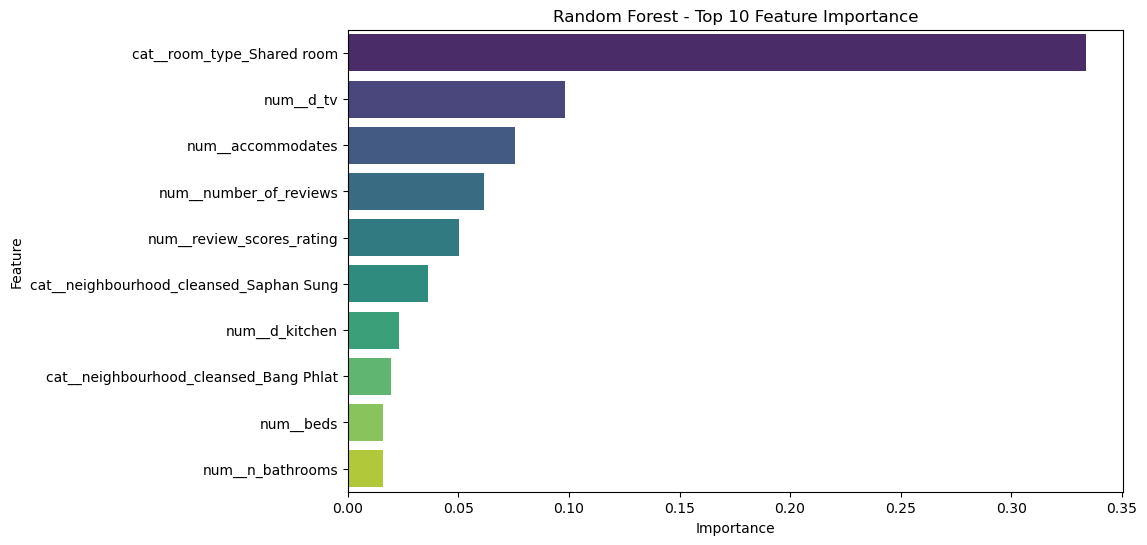

/var/folders/79/nckzxslx7r91k8823vkxyrkh0000gn/T/ipykernel_61528/4123188254.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


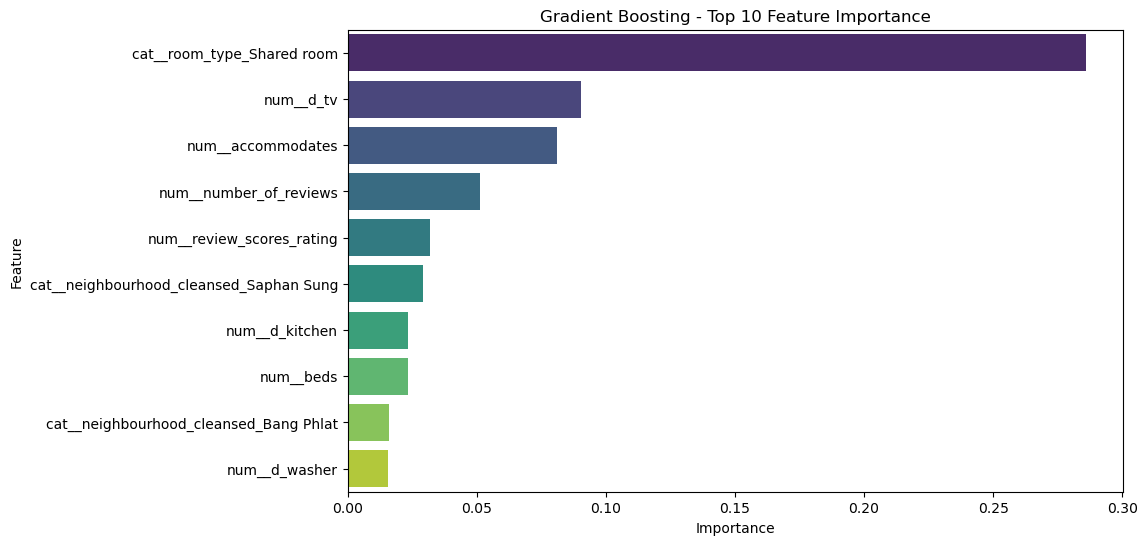

In [16]:
# --- Task 4 Feature Importance Analysis ---
# fit RF and GBM to extract feature importance
print("\nFitting Random Forest and Gradient Boosting models for feature importance analysis...")
models['Random Forest'].fit(X, y)
models['GBM'].fit(X, y)

def plot_importance(model, model_name, top_n=10):
    # 1.get the feature names
    feature_names = model.named_steps['pre'].get_feature_names_out()

    # 2. get feature importance
    regressor = model.named_steps['reg']
    importances = regressor.feature_importances_
    
    # 3. create dataframe for plotting
    feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
    plt.title(f'{model_name} - Top {top_n} Feature Importance')
    plt.show()

# plot feature importance for RF and GBM
plot_importance(models['Random Forest'], 'Random Forest')
plot_importance(models['GBM'], 'Gradient Boosting')


### Feature Importance Discussion

1. **Strong Model Consensus**
   The Random Forest and Gradient Boosting models show remarkable consistency, sharing 9 out of the top 10 features. This high degree of overlap confirms that these variables represent true market signals rather than noise, giving us confidence in the models' reliability.

2. **Room Type is King**
   For both models, `room_type: Shared room` is the #1 predictor. This makes perfect business sense: the fundamental difference between sharing a room and renting a private space is the single biggest factor driving price differences.

3. **Amenities vs. Size**
   Interestingly, specific amenities like TV and Kitchen rank very high—even higher than physical size (`accommodates` or `beds`) in some cases. This suggests that in this specific market (Bangkok), premium facilities are massive price differentiators.

4. **Location Impact**
   The presence of specific neighborhoods (like Saphan Sung and Bang Phlat) in the top 10 confirms that location is critical. The models successfully learned that prices shift significantly depending on the specific district, capturing the "location, location, location" rule of real estate.

## --- PART II ---

In [17]:

from sklearn.metrics import mean_squared_error

In [18]:
# --- Task 5 ---
print("processing data for Bangkok Q3...")
df_bangkok_q3 = clean_data('../data/raw/listings_Bangkok_Q3.csv')

processing data for Bangkok Q3...
Processing file: ../data/raw/listings_Bangkok_Q3.csv ...
Processing complete. Rows remaining: 6859


In [19]:
print("processing data for Singapore Q3...")
df_singapore_q3 = clean_data('../data/raw/listings_Singapore_Q3.csv')

processing data for Singapore Q3...
Processing file: ../data/raw/listings_Singapore_Q3.csv ...
Processing complete. Rows remaining: 2557


In [20]:
# --- Task 6 ---
def evaluate_external_validity(model_dict, file_path, dataset_name):
    print(f"\n--- processing: {dataset_name} ---")
    
    # A. read and clean data (must use the same clean_data function as in Part I)
    try:
        df_new = clean_data(file_path)
    except Exception as e:
        print(f"read or clean data failed: {e}")
        return None

    print(f"Number of remaining rows after cleaning: {len(df_new)}")
    
    if len(df_new) == 0:
        print("fatal error: data is empty, skipping evaluation.")
        return None

    # B. prepare features (X) and target (y)
    y_true = df_new['ln_price']
    X_new = df_new.drop(columns=['id', 'price', 'ln_price'], errors='ignore')
    
    # C. predict and evaluate RMSE
    results = []
    for name, model in model_dict.items():
        try:
            # Pipeline will handle preprocessing
            # handle_unknown='ignore' will handle new categories
            y_pred = model.predict(X_new)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            results.append({'Model': name, f'RMSE ({dataset_name})': rmse})
        except Exception as e:
            print(f"Model {name} prediction failed: {e}")
            results.append({'Model': name, f'RMSE ({dataset_name})': np.nan})
            
    return pd.DataFrame(results).set_index('Model')

In [21]:
# --- set new data paths ---
path_bangkok_q3 = '../data/raw/listings_Bangkok_Q3.csv'   # Data A: Later date
path_singapore = '../data/raw/listings_Singapore_Q3.csv'  # Data B: Other city

In [22]:
# --- make sure all models are retrained on full Bangkok Q2 data ---
print("Retraining on full Bangkok Q2 set...")

for name, model in models.items():
    model.fit(X, y)
    print(f"✅ {name} done.")



Retraining on full Bangkok Q2 set...
✅ OLS done.
✅ LASSO done.
✅ Random Forest done.
✅ GBM done.
✅ Ridge done.


In [23]:
# --- evaluate external validity ---
# A. Time Validity - Bangkok Q3
res_time = evaluate_external_validity(models, path_bangkok_q3, "Bangkok Future")

# B. External Validity - Singapore
res_space = evaluate_external_validity(models, path_singapore, "Singapore")


--- processing: Bangkok Future ---
Processing file: ../data/raw/listings_Bangkok_Q3.csv ...
Processing complete. Rows remaining: 6859
Number of remaining rows after cleaning: 6859

--- processing: Singapore ---
Processing file: ../data/raw/listings_Singapore_Q3.csv ...


/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/minicon

Processing complete. Rows remaining: 2557
Number of remaining rows after cleaning: 2557


/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [24]:
# --- The Final Horserace ---
if res_time is not None and res_space is not None:
    final_table = pd.concat([df_results.set_index('Model'), res_time, res_space], axis=1)
    
    print("\n====== Final Comparison of Model Performance  (RMSE) ======")
    print(final_table.round(4))
    
    final_table.to_csv('../output/final_model_performance.csv')



====== Final Comparison of Model Performance  (RMSE) ======
               CV RMSE  RMSE (Bangkok Future)  RMSE (Singapore)
Model                                                          
GBM             0.2109                 0.1945            1.5017
Random Forest   0.2156                 0.2045            1.4972
LASSO           0.2313                 0.2327            1.5532
OLS             0.2316                 0.2327            1.4935
Ridge           0.2316                 0.2327            1.5000


### Model Performance Comparison & Validity Discussion

1. **Time Validity: Excellent Stability (Bangkok Future)**
   The models performed remarkably well on the "future" data (Bangkok Q3). The error rates (RMSE ≈ 0.19–0.23) are nearly identical to—or even slightly better than—the training results. This proves that the GBM and Random Forest models are stable over time; they learned real pricing patterns that held true into the next quarter.

2. **External Validity: Structural Failure (Singapore)**
   When applied to Singapore, all models failed significantly. The prediction error exploded from ≈ 0.20 to ≈ 1.50. In terms of log-price, an RMSE of 1.50 represents a massive average error, rendering the predictions unusable for business purposes in this new city.

3. **The "Why": Localized Markets**
   This experiment demonstrates that real estate pricing is highly localized.
   * **The Problem:** The models learned "Bangkok rules" (e.g., the base value of a room, the premium for a pool).
   * **The Reality:** Singapore is a completely different economic environment with different baseline prices and amenity values.
   * **Conclusion:** You cannot simply "copy-paste" a pricing model from one country to another. To operate in Singapore, we must retrain the model using local Singaporean data.

In [25]:
# --- Task 7 ---
# --- set target model name ---
target_model_name = 'GBM' 

if target_model_name in models:
    best_model = models[target_model_name]
    print(f"✅ Best model: {target_model_name}")
else:
    print(f"❌ error: cannot find '{target_model_name}' in models dictionary")



✅ Best model: GBM


In [26]:
# --- Error Diagnostics ---
def plot_diagnostic(model, df, title, color_hex):
    # prepare data
    y_true = df['ln_price']
    X = df.drop(columns=['id', 'price', 'ln_price'], errors='ignore')
    
    # predict
    y_pred = model.predict(X)
    
    # plot
    plt.figure(figsize=(8, 6))
    
    # plot scatter (set alpha=0.5 for better visibility of overlapping points)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, color=color_hex, edgecolor='w')
    
    # plot 45-degree reference line (red = perfect prediction)
    # get the unified axis range
    axis_min = min(y_true.min(), y_pred.min())
    axis_max = max(y_true.max(), y_pred.max())
    plt.plot([axis_min, axis_max], [axis_min, axis_max], 'r--', lw=2, label='Perfect Prediction (45°)')
    
    # labels and title
    plt.xlabel(f'Actual Log Price ({title})')
    plt.ylabel(f'Predicted Log Price (by {target_model_name})')
    plt.title(f'Task 7 Diagnostic: {target_model_name} on {title}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


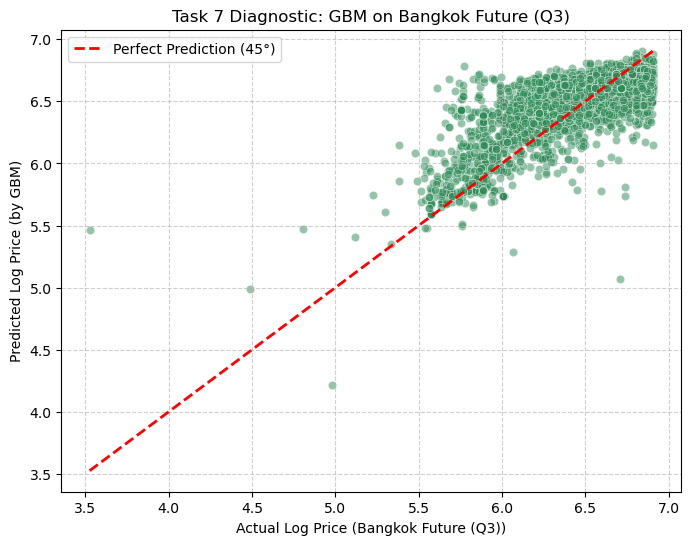

/opt/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


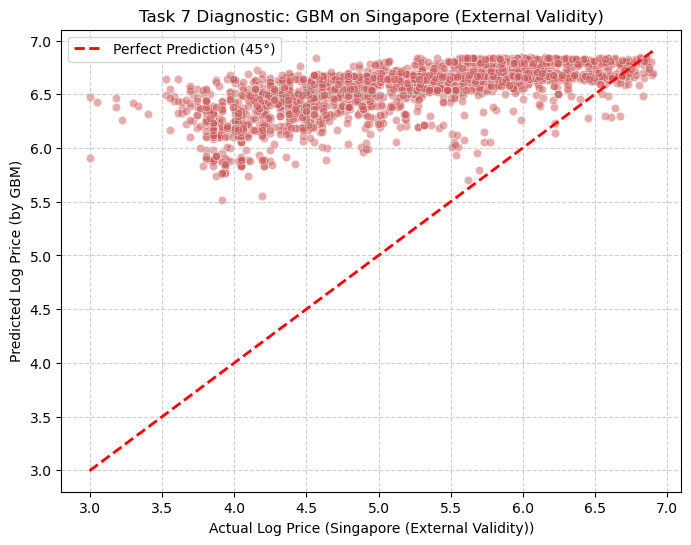

In [27]:
# --- Plot Diagnostic Results ---

# fig A: time validity (Bangkok Q3) - expected: points cluster around red line
# use color 'seagreen' (green represents pass/safe)
if 'df_bangkok_q3' in locals():
    plot_diagnostic(best_model, df_bangkok_q3, "Bangkok Future (Q3)", 'seagreen')

# fig B: external validity (Singapore Q3) - expected: points deviate from red line
# use color 'indianred' (red represents warning/deviation)
if 'df_singapore_q3' in locals():
    plot_diagnostic(best_model, df_singapore_q3, "Singapore (External Validity)", 'indianred')

### Task 7 Discussion: Diagnostics & External Validity

1. **Unexpected Overestimation**
   The diagnostic plot reveals a surprising pattern: most Singapore data points lie above the 45-degree line. This means the model consistently predicted prices higher than the actual values (Predicted > Actual). This is counter-intuitive, as we usually expect a model trained in a lower-income city (Bangkok) to underestimate prices in a higher-income city (Singapore).

2. **The "Luxury vs. Standard" Mismatch**
   The likely cause is a structural difference in how amenities are valued. In Bangkok, features like air conditioning, pools, or gyms are often treated as "luxuries" and command a high price premium. In Singapore, these are often standard expectations for housing. The model incorrectly applied Bangkok's high "luxury markup" to standard Singaporean listings, inflating the predicted prices.

3. **Conclusion on Validity**
   This visual evidence confirms that External Validity failed. It highlights that pricing models are not just about GDP differences; they are deeply sensitive to local market standards. A feature that is a "price driver" in one city may be irrelevant in another, proving that local retraining is necessary for expansion.